In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
import seaborn as sns

np.random.seed((42))

#assume 10,000 visitors each
n_A, p_A = 10_000, 0.10  # Varirant A: 10% true conversion
n_B, p_B = 10_000, 0.12  # Variant B: 12% true conversion

#simulate number of purchase
success_A = np.random.binomial(n_A, p_A)
success_B = np.random.binomial(n_B, p_B)

In [ ]:
print(success_A)
print(success_B)

973
1134


In [ ]:
# Calculate Conversion RAtes & 95% CIs

def proportion_ci(successes, n, alpha=0.05):
    p_hat = successes / n
    z = stats.norm.ppf(1 - alpha / 2)
    se = np.sqrt(p_hat * (1 - p_hat) / n) #Standard error
    return p_hat, p_hat - z*se, p_hat + z*se

p_A_hat, ci_low_A, ci_high_A = proportion_ci(success_A, n_A)
p_B_hat, ci_low_B, ci_high_B = proportion_ci(success_B, n_B)

results = pd.DataFrame({
    'Variant': ['A','B'],
    'Visitors': [n_A, n_B],
    'Conversions': [success_A, success_B],
    'CR (p̂)' : [p_A_hat, p_B_hat],
    'CI Lower (95%)': [ci_low_A, ci_low_B],
    'CI Upper (95%)': [ci_high_A, ci_high_B],
})
print(results)

  Variant  Visitors  Conversions  CR (p̂)  CI Lower (95%)  CI Upper (95%)
0       A     10000          973   0.0973        0.091491        0.103109
1       B     10000         1134   0.1134        0.107185        0.119615


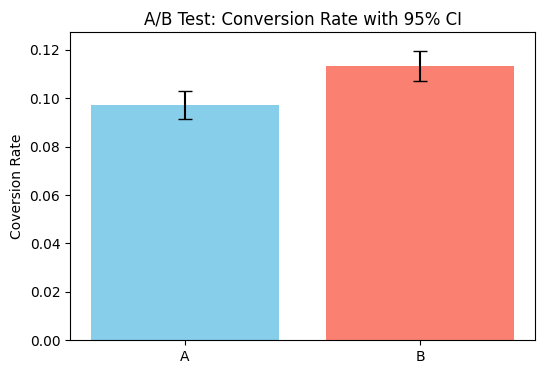

In [ ]:
#Plot Conversion Rates with Error Bars
plt.figure(figsize=(6,4))
plt.bar(
    results['Variant'],
    results['CR (p̂)'],
    yerr=[
        results['CR (p̂)'] - results['CI Lower (95%)'],
        results['CI Upper (95%)'] - results['CR (p̂)']
    ],
    capsize=5,
    color=['skyblue','salmon']
)
plt.ylabel('Coversion Rate')
plt.title('A/B Test: Conversion Rate with 95% CI')
plt.ylim(0, max(results['CI Lower (95%)'])+ 0.02) #yaxis-limiter
plt.show()

In [ ]:
# Two-Proportion z-test
count = np.array([success_B, success_A])
nobs = np.array([n_B, n_A])

z_stat, p_value = proportions_ztest(count, nobs, alternative='larger')
print(f'Z-statistic: {z_stat:.3f}')
print(f'p-value: {p_value:.3f}')

if p_value < 0.05:
  print("-> Reject H0: Variant B has a significantly higher conversion rate than Variant A")
else:
  print("-> Fail to reject H0: No significant lift from B over A")

Z-statistic: 3.708
p-value: 0.000
-> Reject H0: Variant B has a significantly higher conversion rate than Variant A


In [ ]:
import time
from IPython.display import clear_output

true_p_A, true_p_B = 0.10, 0.12
batch_size = 100
n_batches = 60

n_visits_A = n_visits_B = 0
n_succ_A = n_succ_B = 0

batches = []
p_values = []
lifts = []

Batch: 60/60
 Variant A: 12000 visits, 1184 buys -> CR = 0.099
 Variant B: 12000 visits, 1411 buys -> CR = 0.118
 Observed lift : 1.892%
 z-stat: 4.72, p-value: 0.0000
 -> Significant lift detected (p<0.05).


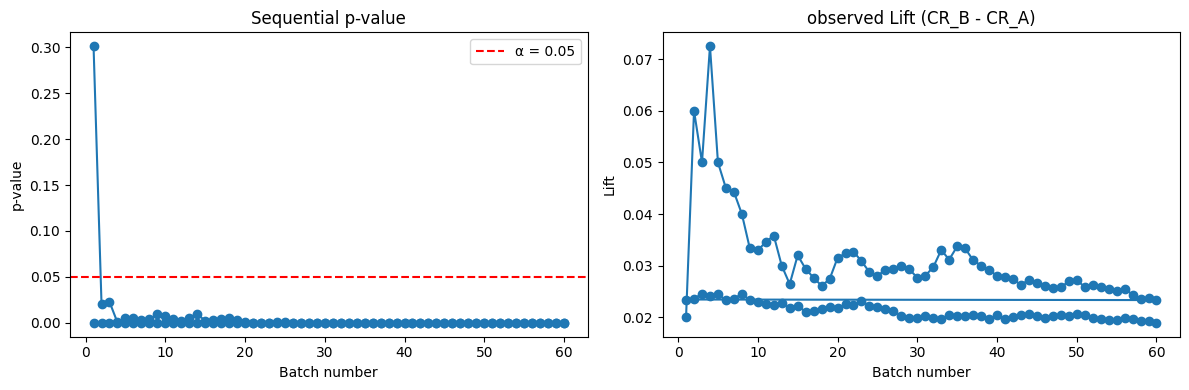

In [ ]:
for batch in range(1, n_batches+1):
  new_A = np.random.binomial(batch_size, true_p_A)
  new_B = np.random.binomial(batch_size, true_p_B)

# update tools
  n_visits_A += batch_size
  n_visits_B += batch_size
  n_succ_A += new_A
  n_succ_B += new_B

# Compute current conversion rates
  cr_A = n_succ_A / n_visits_A
  cr_B = n_succ_B / n_visits_B
  lift = cr_B - cr_A

# two-proportion z-test(one sided: B>A)
  count = np.array([n_succ_B, n_succ_A])
  nobs = np.array([n_visits_B, n_visits_A])
  z_stat, p_val = proportions_ztest(count, nobs, alternative='larger')

#Record for plotting
  batches.append(batch)
  p_values.append(p_val)
  lifts.append(lift)

# Clear previous output and print current stats
  clear_output(wait=True)
  print(f'Batch: {batch}/{n_batches}')
  print(f" Variant A: {n_visits_A} visits, {n_succ_A} buys -> CR = {cr_A:.3f}")
  print(f" Variant B: {n_visits_B} visits, {n_succ_B} buys -> CR = {cr_B:.3f}")
  print(f" Observed lift : {lift:.3%}")
  print(f" z-stat: {z_stat:.2f}, p-value: {p_val:.4f}")
  if p_val < 0.05:
    print(" -> Significant lift detected (p<0.05).")
  else:
    print(" -> No significant lift yet.")

  #Plot
  fig, axes = plt.subplots(1, 2, figsize=(12,4))
  axes[0].plot(batches, p_values, '-o')
  axes[0].axhline(0.05, color='red', linestyle='--', label='α = 0.05')
  axes[0].set_title('Sequential p-value')
  axes[0].set_xlabel('Batch number')
  axes[0].set_ylabel('p-value')
  axes[0].legend()

  axes[1].plot(batches, lifts, '-o')
  axes[1].set_title('observed Lift (CR_B - CR_A)')
  axes[1].set_xlabel('Batch number')
  axes[1].set_ylabel('Lift')

  plt.tight_layout()
  plt.show()

  time.sleep(0.9)